In [ ]:
import os
import sys

from constant.path import PROJECT_ROOT

# Jika project root belum ada di sys.path, tambahkan
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Ganti direktori kerja ke project root agar semua import relatif bekerja dengan benar
os.chdir(PROJECT_ROOT)

In [ ]:
import pandas as pd

from constant.path import MASTER_DATASET_PATH

df = pd.read_csv(MASTER_DATASET_PATH)
df.head()

,data_id,domain,viewport,image_path,text_path,label_name,label_code
0,JD_001_DSK,garuda368jp.art,desktop,dataset/images/gambling/garuda368jp.art_deskto...,dataset/texts/gambling/garuda368jp.art_desktop...,judi,1
1,JD_001_MBL,garuda368jp.art,mobile,dataset/images/gambling/garuda368jp.art_mobile...,dataset/texts/gambling/garuda368jp.art_mobile.txt,judi,1
2,JD_002_DSK,gacor108b.xyz,desktop,dataset/images/gambling/gacor108b.xyz_desktop.png,dataset/texts/gambling/gacor108b.xyz_desktop.txt,judi,1
3,JD_002_MBL,gacor108b.xyz,mobile,dataset/images/gambling/gacor108b.xyz_mobile.png,dataset/texts/gambling/gacor108b.xyz_mobile.txt,judi,1
4,JD_003_DSK,kuda898jepe.online,desktop,dataset/images/gambling/kuda898jepe.online_des...,dataset/texts/gambling/kuda898jepe.online_desk...,judi,1


In [3]:
df.value_counts()

data_id     domain                 viewport  image_path                                                    text_path                                                    label_name  label_code
JD_001_DSK  garuda368jp.art        desktop   dataset/images/gambling/garuda368jp.art_desktop.png           dataset/texts/gambling/garuda368jp.art_desktop.txt           judi        1             1
JD_001_MBL  garuda368jp.art        mobile    dataset/images/gambling/garuda368jp.art_mobile.png            dataset/texts/gambling/garuda368jp.art_mobile.txt            judi        1             1
JD_002_DSK  gacor108b.xyz          desktop   dataset/images/gambling/gacor108b.xyz_desktop.png             dataset/texts/gambling/gacor108b.xyz_desktop.txt             judi        1             1
JD_002_MBL  gacor108b.xyz          mobile    dataset/images/gambling/gacor108b.xyz_mobile.png              dataset/texts/gambling/gacor108b.xyz_mobile.txt              judi        1             1
JD_003_DSK  kuda898jepe.o

In [ ]:
import torch

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label_code'],
    random_state=42
)

print(f"Total Training: {len(train_df)}")
print(f"Total Validation: {len(val_df)}")

Total Training: 2400
Total Validation: 600


In [ ]:
import os

from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from constant.path import PROJECT_ROOT


class GamblingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(PROJECT_ROOT, self.dataframe.iloc[idx]['image_path'])
        label = self.dataframe.iloc[idx]['label_code']

        # Load gambar dan pastikan RGB
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# Transformasi: Resize ke 224 dan Normalisasi ImageNet
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Augmentasi aman untuk screenshot web
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Buat DataLoader
train_loader = DataLoader(GamblingDataset(train_df, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(GamblingDataset(val_df, val_transform), batch_size=32)

In [ ]:
import torch.nn as nn
from torchvision import models


class GamblingClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Load EfficientNet-B0 pretrained
        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.model = models.efficientnet_b0(weights=weights)

        # Ambil jumlah fitur terakhir dari classifier
        in_features = self.model.classifier[1].in_features

        # Replace classifier untuk binary classification
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_features, 1)  # 1 output → binary
        )

    def forward(self, x):
        return self.model(x)

model = GamblingClassifier().to(device)

In [ ]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
from tqdm.auto import tqdm


def train_one_epoch(epoch: int):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # leave=False agar tidak menumpuk di terminal.
    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Hitung akurasi
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Update progress bar dengan loss terbaru
        loop.set_postfix(loss=loss.item())

    return total_loss / len(train_loader), correct / total

def validate():
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # Loop validasi juga bisa diberi progress bar
    loop = tqdm(val_loader, desc="Validating", leave=False)

    with torch.no_grad():
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(val_loader), correct / total

In [ ]:
from termcolor import RESET

from constant.color import BLUE, GREEN
from constant.path import EFFICIENTNET_B0_MODEL_PATH

epochs = 10
best_acc = 0

# Inisialisasi progress bar utama
pbar = tqdm(range(epochs), desc="Training Progress")

for epoch in pbar:
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = validate()

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), EFFICIENTNET_B0_MODEL_PATH)

        # Menggunakan warna hijau untuk memberi tahu model disimpan
        pbar.write(f"{GREEN}⭐ Epoch {epoch+1}: New best accuracy {best_acc:.4f} - Model Saved!{RESET}")
    else:
        # Menggunakan warna biru untuk log standar
        pbar.write(f"{BLUE}i{RESET} Epoch {epoch+1}: Val Acc {val_acc:.4f}")

    pbar.set_postfix({
        "T-Loss": f"{train_loss:.4f}",
        "V-Acc": f"{val_acc:.4f}",
        "Best": f"{best_acc:.4f}"
    })

print(f"\n✅ Training Complete! Best Accuracy: {best_acc:.4f}")

Epoch 1/10
Train Loss: 0.2809 | Acc: 0.9333
Val Loss: 0.0682 | Acc: 0.9783
------------------------------
Model saved!
Epoch 2/10
Train Loss: 0.0757 | Acc: 0.9758
Val Loss: 0.0356 | Acc: 0.9867
------------------------------
Model saved!
Epoch 3/10
Train Loss: 0.0324 | Acc: 0.9921
Val Loss: 0.0283 | Acc: 0.9883
------------------------------
Model saved!
Epoch 4/10
Train Loss: 0.0212 | Acc: 0.9967
Val Loss: 0.0238 | Acc: 0.9917
------------------------------
Model saved!
Epoch 5/10
Train Loss: 0.0165 | Acc: 0.9962
Val Loss: 0.0204 | Acc: 0.9900
------------------------------
Epoch 6/10
Train Loss: 0.0126 | Acc: 0.9971
Val Loss: 0.0210 | Acc: 0.9917
------------------------------
Epoch 7/10
Train Loss: 0.0128 | Acc: 0.9975
Val Loss: 0.0180 | Acc: 0.9950
------------------------------
Model saved!
Epoch 8/10
Train Loss: 0.0093 | Acc: 0.9975
Val Loss: 0.0178 | Acc: 0.9900
------------------------------
Epoch 9/10
Train Loss: 0.0046 | Acc: 0.9988
Val Loss: 0.0127 | Acc: 0.9967
------------

In [ ]:
import matplotlib.pyplot as plt


def predict(image_path):
    model.load_state_dict(torch.load(EFFICIENTNET_B0_MODEL_PATH, map_location=device))
    model.eval()

    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output).item()

    label = "JUDI" if prob > 0.5 else "BUKAN JUDI"
    print(f"Hasil Prediksi: {label} ({prob*100:.2f}%)")
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Contoh penggunaan:
# predict('path/to/test/image.png')

In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix


def get_all_preds(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).squeeze()

            # Ubah logit menjadi probabilitas (0-1) lalu ke label (0 atau 1)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Ambil label asli dan hasil prediksi dari validation loader
y_true, y_pred = get_all_preds(model, val_loader)

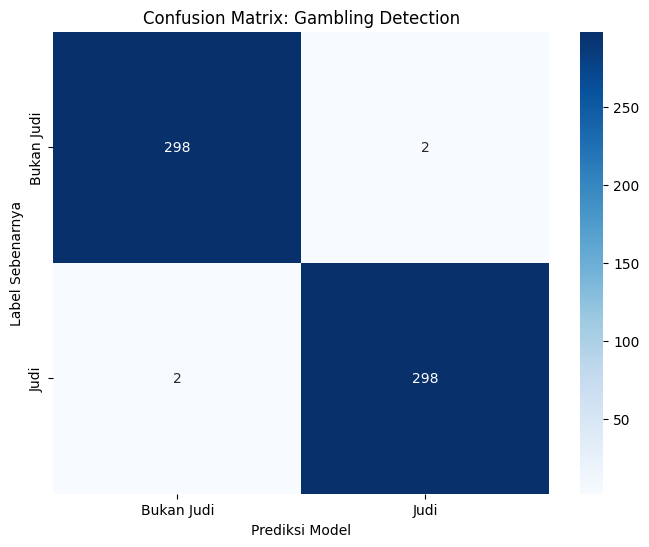


Classification Report:
              precision    recall  f1-score   support

  Bukan Judi       0.99      0.99      0.99       300
        Judi       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



In [13]:
import seaborn as sns


def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bukan Judi', 'Judi'],
                yticklabels=['Bukan Judi', 'Judi'])

    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Sebenarnya')
    plt.title('Confusion Matrix: Gambling Detection')
    plt.show()

    # Cetak laporan lengkap (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Bukan Judi', 'Judi']))

plot_confusion_matrix(y_true, y_pred)